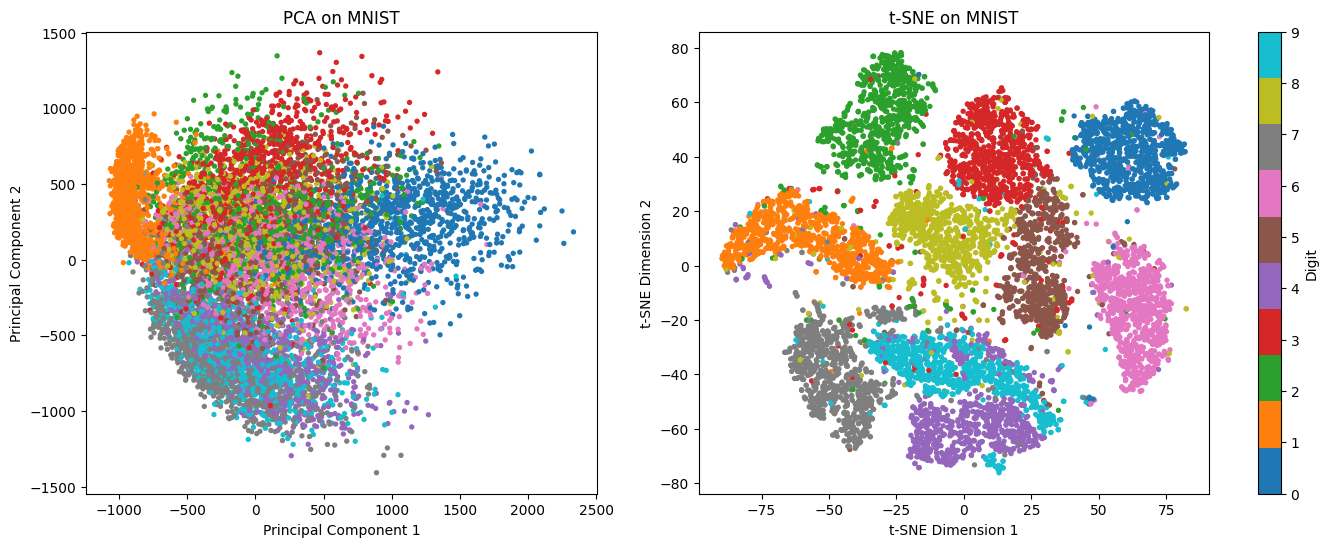

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# Use a subset because t-SNE is computationally expensive
n_samples = 10000
X = X[:n_samples]
y = y[:n_samples]

# -----------------------
# PCA
# -----------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# -----------------------
# t-SNE
# -----------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# -----------------------
# Plot
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA Plot
scatter = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='tab10',
    s=8
)
axes[0].set_title("PCA on MNIST")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# t-SNE Plot
axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='tab10',
    s=8
)
axes[1].set_title("t-SNE on MNIST")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

# Leave room on the right for the colorbar
plt.subplots_adjust(right=0.88)

# Colorbar outside both plots
cbar = fig.colorbar(
    scatter,
    ax=axes,
    location='right',
    fraction=0.03,
    pad=0.04,
    ticks=range(10)
)
cbar.set_label("Digit")

plt.show()
